- 데이터셋 이름 : Amazon Sales Dataset
- 데이터 출처 URL : https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset
- 이 데이터를 선택한 이유 : 온라인 마켓 동향 파악을 위해
- 각 행이 무엇을 의미하는지 (관측 단위) : 
한 행 = 특정 상품(product_id)의 가격, 할인율, 별점, 리뷰 등

- 주요 컬럼의 의미 : 

| 컬럼 | 설명 |
|---|---|
| `product_id` | 상품 고유 식별자 |
| `product_name` | 상품명 |
| `category` | 상품 카테고리, `대분류\|중분류\|...\|최하위분류` 형태의 계층 구조 (최대 7단계) |
| `discounted_price` | 할인된 판매가 (₹, 인도 루피) |
| `actual_price` | 할인 전 정가 (₹) |
| `discount_percentage` | 할인율 (%) |
| `rating` | 상품의 평균 평점 (보통 5점 만점) |
| `rating_count` | 그 평점을 매긴 사람 수 (평가 신뢰도 지표) |
| `about_product` | 상품 설명 |
| `user_id`, `user_name` | 리뷰 작성자 식별자/이름 |
| `review_id` | 리뷰 고유 식별자 |
| `review_title`, `review_content` | 리뷰 제목/본문 |
| `img_link` | 상품 이미지 URL |
| `product_link` | 상품 페이지 URL |


In [33]:
# 아마존 sales 데이터셋을 활용한 연습
import pandas as pd
amazon_sales = pd.read_csv("amazon.csv")

In [34]:
amazon_sales.shape

(1465, 16)

In [35]:
# img_link와 product_link 컬럼은 분석에 필요하지 않으므로 제거
amazon_sales = amazon_sales.drop(columns=["img_link", "product_link"])

In [36]:
# 1단계: 중복 삭제
print(amazon_sales.duplicated().sum()) 
amazon_sales = amazon_sales.drop_duplicates()
print(amazon_sales.duplicated().sum())

65
0


In [37]:
# 2단계: 문자열 정제
# discounted_price, actual_price: ₹ 기호와 천단위 콤마 제거
for col in ["discounted_price", "actual_price"]:
    amazon_sales[col] = (
        amazon_sales[col]
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# discount_percentage: % 기호 제거
amazon_sales["discount_percentage"] = (
    amazon_sales["discount_percentage"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

# rating_count: 천단위 콤마 제거
amazon_sales["rating_count"] = (
    amazon_sales["rating_count"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

# rating: "|" 같은 비정상 값이 섞여 있으므로 안전하게 숫자 변환 (실패 시 NaN)
amazon_sales["rating"] = pd.to_numeric(amazon_sales["rating"], errors="coerce")

# 결과 확인
amazon_sales.dtypes

product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
about_product              str
user_id                    str
user_name                  str
review_id                  str
review_title               str
review_content             str
dtype: object

In [38]:
# 3단계: 날쨔 파싱 - 날짜가 존재하지 않으므로 생략

In [39]:
# 4단계: 이상치 처리 — 탐색용 코드

# 1) 논리적 이상치 확인
print("가격 역전(할인가 > 정가):", (amazon_sales["discounted_price"] > amazon_sales["actual_price"]).sum())
print("rating 범위 이탈(0~5):", ((amazon_sales["rating"] < 0) | (amazon_sales["rating"] > 5)).sum())
print("discount_percentage 범위 이탈(0~100):", ((amazon_sales["discount_percentage"] < 0) | (amazon_sales["discount_percentage"] > 100)).sum())

# 2) IQR 기준 이상치 판별 함수
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# 3) 컬럼별 이상치 개수 + 경계값 확인
for col in ["discounted_price", "actual_price", "discount_percentage", "rating_count"]:
    lower, upper = iqr_bounds(amazon_sales[col])
    mask = (amazon_sales[col] < lower) | (amazon_sales[col] > upper)
    print(f"{col}: 경계=({lower:.1f}, {upper:.1f}), 이상치 {mask.sum()}건")

# 4) 특정 컬럼의 이상치 행을 직접 눈으로 확인 (컬럼명 바꿔가며 사용)
col = "discounted_price"
lower, upper = iqr_bounds(amazon_sales[col])
outliers = amazon_sales[(amazon_sales[col] < lower) | (amazon_sales[col] > upper)]
outliers[["product_id", "product_name", "category", col]].sort_values(col, ascending=False)


가격 역전(할인가 > 정가): 0
rating 범위 이탈(0~5): 0
discount_percentage 범위 이탈(0~100): 0
discounted_price: 경계=(-2284.0, 4724.0), 이상치 214건
actual_price: 경계=(-4671.2, 10182.8), 이상치 187건
discount_percentage: 경계=(-17.0, 111.0), 이상치 0건
rating_count: 경계=(-23163.0, 41761.0), 이상치 135건


,product_id,product_name,category,discounted_price
249,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",77990.0
325,B095JPKPH3,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,"Electronics|HomeTheater,TV&Video|Televisions|S...",61999.0
255,B0BC8BQ432,VU 164 cm (65 inches) The GloLED Series 4K Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",54990.0
192,B0B15GSPQW,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0
283,B0B3XXSB1K,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0
...,...,...,...,...
1299,B0B53DS4TF,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,4995.0
1405,B0BBWJFK5C,Shakti Technology S3 High Pressure Car Washer ...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",4899.0
1260,B008P7IF02,Morphy Richards New Europa 800-Watt Espresso a...,"Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...",4799.0
405,B08FN6WGDQ,Samsung Galaxy Buds Live Bluetooth Truly Wirel...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4790.0


In [40]:
# 5) 상위/하위 극단값만 빠르게 훑어보기
amazon_sales.nlargest(10, col)[["product_name", "category", col]]

,product_name,category,discounted_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",77990.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,"Electronics|HomeTheater,TV&Video|Televisions|S...",61999.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",54990.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,"Electronics|HomeTheater,TV&Video|Televisions|S...",46999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,"Electronics|HomeTheater,TV&Video|Televisions|S...",45999.0
533,"OnePlus 10T 5G (Moonstone Black, 8GB RAM, 128G...",Electronics|Mobiles&Accessories|Smartphones&Ba...,44999.0
216,OnePlus 138.7 cm (55 inches) U Series 4K LED S...,"Electronics|HomeTheater,TV&Video|Televisions|S...",42999.0
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,"Home&Kitchen|Heating,Cooling&AirQuality|AirCon...",42990.0


In [41]:
amazon_sales.nsmallest(10, col)[["product_name", "category", col]]

,product_name,category,discounted_price
645,GIZGA essentials Universal Silicone Keyboard P...,Computers&Accessories|Accessories&Peripherals|...,39.00
975,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,Computers&Accessories|Accessories&Peripherals|...,39.00
997,Inventis 5V 1.2W Portable Flexible USB LED Lig...,Computers&Accessories|Accessories&Peripherals|...,39.00
616,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,OfficeProducts|OfficePaperProducts|Paper|Stati...,50.00
178,FLiX (Beetel Flow USB to Micro USB PVC Data Sy...,Computers&Accessories|Accessories&Peripherals|...,57.89
23,Flix Micro Usb Cable For Smartphone (Black),Computers&Accessories|Accessories&Peripherals|...,59.00
44,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,Computers&Accessories|Accessories&Peripherals|...,59.00
478,Flix Micro Usb Cable For Smartphone (Black),Computers&Accessories|Accessories&Peripherals|...,59.00
710,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,Computers&Accessories|Accessories&Peripherals|...,59.00
811,Classmate Pulse Spiral Notebook - 240 mm x 180...,OfficeProducts|OfficePaperProducts|Paper|Stati...,67.00


이 이상치들은 대부분 "데이터 오류"가 아니라 정상적으로 존재하는 고가 상품·인기 상품(예: TV, 노트북처럼 원래 비싼 상품, 리뷰가 수십만 개인 베스트셀러)

따라서 이상치 제거가 칠요하지 않음.

In [42]:
# 5단계: 결측치 처리

# 1) 결측치 현황 재확인
print(amazon_sales.isna().sum())

# 2) 결측치가 있는 행 직접 확인
amazon_sales[amazon_sales.isna().any(axis=1)]

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
dtype: int64


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
282,B0B94JPY2N,Amazon Brand - Solimo 65W Fast Charging Braide...,Computers&Accessories|Accessories&Peripherals|...,199.0,999.0,80.0,3.0,NaN,USB C to C Cable: This cable has type C connec...,AE7CFHY23VAJT2FI4NZKKP6GS2UQ,Pranav,RUB7U91HVZ30,The cable works but is not 65W as advertised,I have a pd supported car charger and I bought...
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,249.0,999.0,75.0,5.0,NaN,💎[The Fastest Charge] - This iPhone USB C cabl...,AGJC5O5H5BBXWUV7WRIEIOOR3TVQ,Abdul Gafur,RQXD5SAMMPC6L,Awesome Product,Quick delivery.Awesome ProductPacking was good...
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,16.0,NaN,992.0,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though..."


결측치의 갯수가 매우 작고 rating과 rating_count간의 상관 관계가 있으므로(rating이 있는데	rating_count가 없을 수 없고, rating이 없는데 rating_count가 없을 수 없으므로) 결측 행에 대하여 drop한다.

In [43]:
amazon_sales = amazon_sales.dropna(subset=["rating", "rating_count"])

In [44]:

amazon_sales.shape

(1397, 14)

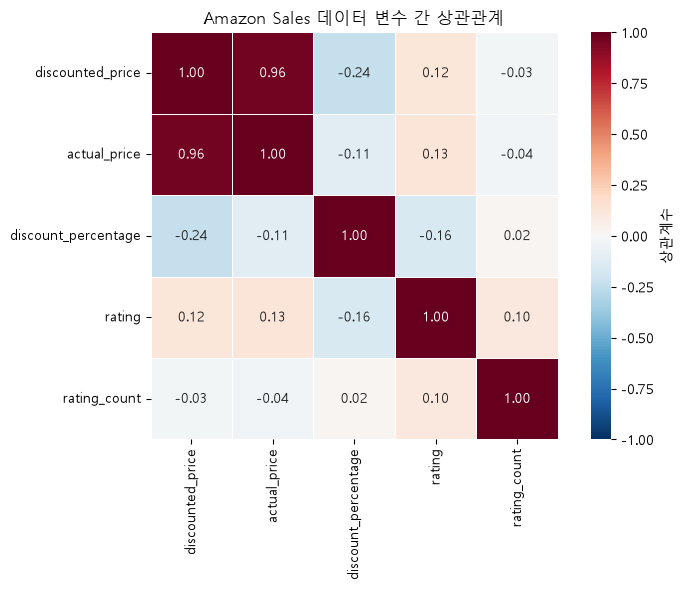

                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.961575            -0.238834   
actual_price                 0.961575      1.000000            -0.112060   
discount_percentage         -0.238834     -0.112060             1.000000   
rating                       0.124900      0.125992            -0.161384   
rating_count                -0.029062     -0.037947             0.016961   

                       rating  rating_count  
discounted_price     0.124900     -0.029062  
actual_price         0.125992     -0.037947  
discount_percentage -0.161384      0.016961  
rating               1.000000      0.104469  
rating_count         0.104469      1.000000  


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 상관관계 계산
num_cols = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]
corr = amazon_sales[num_cols].corr()

# 2) 히트맵 시각화 (diverging: 음의 상관 ~ 0 ~ 양의 상관)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",      # 음(파랑) - 중립(흰색) - 양(빨강)
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "상관계수"}
)
plt.title("Amazon Sales 데이터 변수 간 상관관계")
plt.tight_layout()
plt.show()

# 3) 상관계수 값 자체도 텍스트로 확인
print(corr)

                       상품수      평균평점         평균평가수        총평가수
category_main                                                 
Electronics            515  4.079612  30423.285437  15667992.0
Home&Kitchen           447  4.040716   6689.210291   2990077.0
Computers&Accessories  397  4.154660  17504.488665   6949282.0
OfficeProducts          31  4.309677   4828.225806    149675.0
MusicalInstruments       2  3.900000  44441.000000     88882.0
HomeImprovement          2  4.250000   4283.000000      8566.0
Car&Motorbike            1  3.800000   1118.000000      1118.0
Health&PersonalCare      1  4.000000   3663.000000      3663.0
Toys&Games               1  4.300000  15867.000000     15867.0


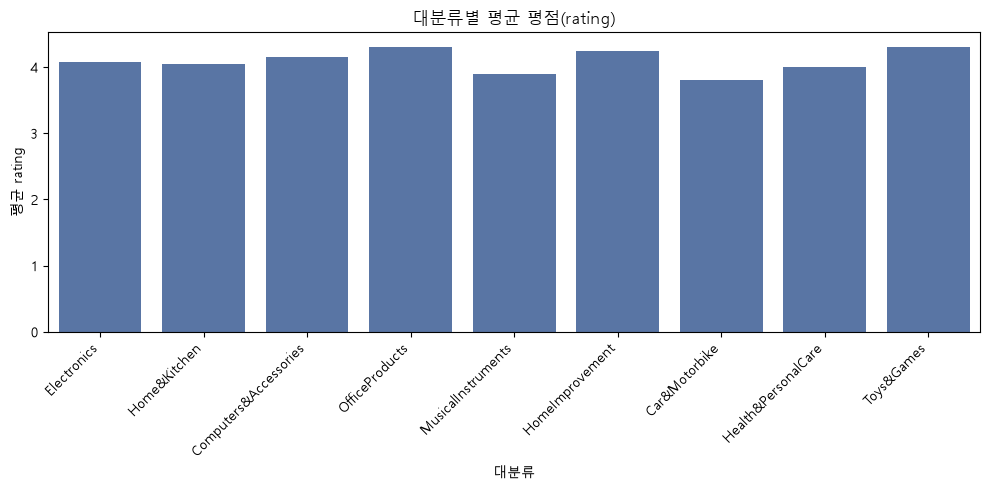

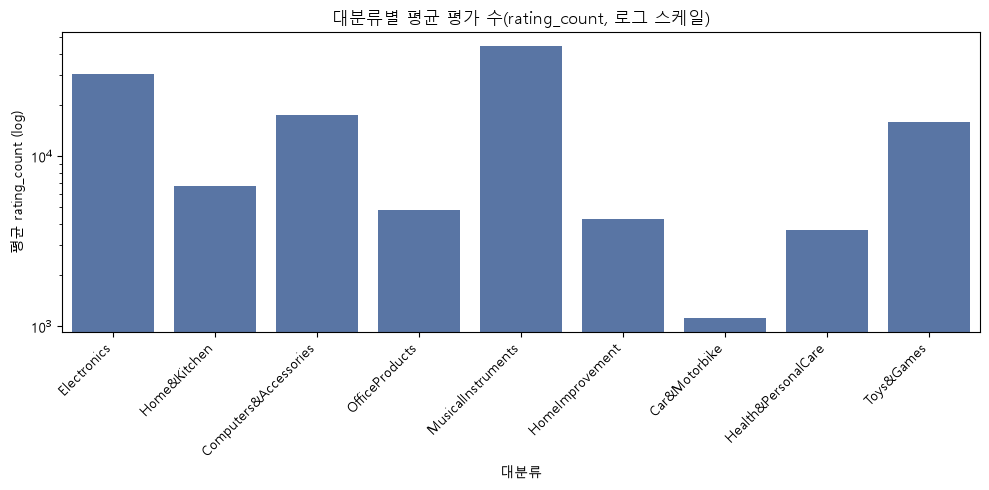

In [46]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows 기본 내장 폰트)
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
# 1) 대분류 컬럼 생성 (category의 첫 번째 레벨)
amazon_sales["category_main"] = amazon_sales["category"].str.split("|").str[0]

# 2) 대분류별 rating, rating_count 요약 통계
summary = amazon_sales.groupby("category_main").agg(
    상품수=("product_id", "count"),
    평균평점=("rating", "mean"),
    평균평가수=("rating_count", "mean"),
    총평가수=("rating_count", "sum")
).sort_values("상품수", ascending=False)

print(summary)

# 3) 대분류별 평균 rating 막대그래프
plt.figure(figsize=(10, 5))
order = summary.index
sns.barplot(
    data=amazon_sales,
    x="category_main", y="rating",
    order=order,
    color="#4C72B0",
    errorbar=None
)
plt.xticks(rotation=45, ha="right")
plt.title("대분류별 평균 평점(rating)")
plt.ylabel("평균 rating")
plt.xlabel("대분류")
plt.tight_layout()
plt.show()

# 4) 대분류별 평균 rating_count 막대그래프 (분포가 넓으므로 로그 스케일 고려)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=amazon_sales,
    x="category_main", y="rating_count",
    order=order,
    color="#4C72B0",
    errorbar=None
)
plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.title("대분류별 평균 평가 수(rating_count, 로그 스케일)")
plt.ylabel("평균 rating_count (log)")
plt.xlabel("대분류")
plt.tight_layout()
plt.show()

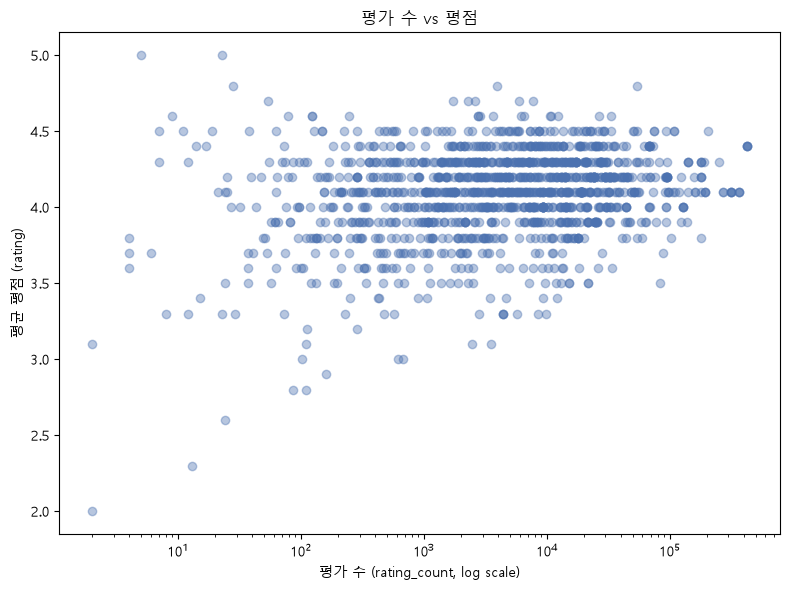

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(amazon_sales["rating_count"], amazon_sales["rating"], alpha=0.4, color="#4C72B0")
plt.xscale("log")  # rating_count 편차가 크므로 로그 스케일
plt.xlabel("평가 수 (rating_count, log scale)")
plt.ylabel("평균 평점 (rating)")
plt.title("평가 수 vs 평점")
plt.tight_layout()
plt.show()

rating_count 기준(중앙값): 5137.0
rating 기준(중앙값): 4.1
검증된 인기 상품 개수: 492
category_main
Electronics              215
Computers&Accessories    171
Home&Kitchen              92
OfficeProducts            12
Toys&Games                 1
HomeImprovement            1
Name: count, dtype: int64


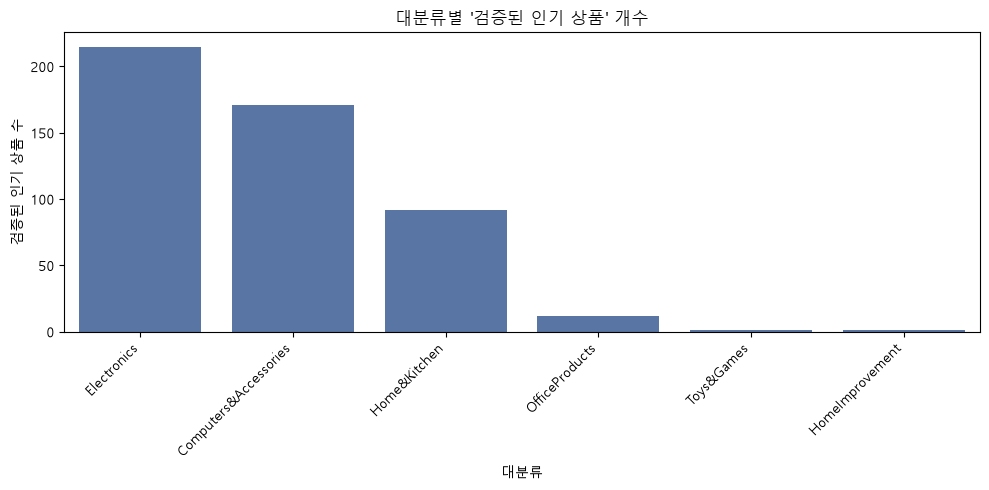

대분류별 '검증된 인기 상품' 비율(%):
category_main
Toys&Games               100.0
HomeImprovement           50.0
Computers&Accessories     43.1
Electronics               41.7
OfficeProducts            38.7
Home&Kitchen              20.6
Car&Motorbike              NaN
Health&PersonalCare        NaN
MusicalInstruments         NaN
Name: count, dtype: float64


In [48]:
# 1) 대분류 컬럼 (없다면 생성)
amazon_sales["category_main"] = amazon_sales["category"].str.split("|").str[0]

# 2) "검증된 인기 상품" 기준 정의 (중앙값 이상을 기준으로)
count_th = amazon_sales["rating_count"].median()
rating_th = amazon_sales["rating"].median()

print(f"rating_count 기준(중앙값): {count_th}")
print(f"rating 기준(중앙값): {rating_th}")

popular_good = amazon_sales[
    (amazon_sales["rating_count"] >= count_th) &
    (amazon_sales["rating"] >= rating_th)
]

print("검증된 인기 상품 개수:", len(popular_good))

# 3) 대분류별 개수 집계
cat_counts = popular_good["category_main"].value_counts()
print(cat_counts)

# 4) 막대그래프로 시각화
plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("검증된 인기 상품 수")
plt.xlabel("대분류")
plt.title("대분류별 '검증된 인기 상품' 개수")
plt.tight_layout()
plt.show()

# 5) 참고: 전체 상품 대비 비율로도 확인 (특정 카테고리가 원래 상품 수가 많아서 그런건지 체크)
ratio = (popular_good["category_main"].value_counts() / amazon_sales["category_main"].value_counts() * 100).round(1)
print("대분류별 '검증된 인기 상품' 비율(%):")
print(ratio.sort_values(ascending=False))

In [49]:
amazon_sales.to_parquet("d009_outputs/amazon_sales_clean.parquet", index=False)
amazon_sales.to_csv("d009_outputs/amazon_sales_clean.csv", index=False)

import os
parquet_size = os.path.getsize("d009_outputs/amazon_sales_clean.parquet")
csv_size = os.path.getsize("d009_outputs/amazon_sales_clean.csv")
print(f"Parquet은 CSV 대비 약 {csv_size / parquet_size:.1f}배 작음 ({parquet_size:,} bytes vs {csv_size:,} bytes)")

Parquet은 CSV 대비 약 1.9배 작음 (2,262,733 bytes vs 4,252,808 bytes)


## 아마존 세일즈 데이터 정제·집계 보고서

### 1. 데이터 개요

- **데이터 출처**: `amazon.csv` (Amazon 인도 상품 판매/리뷰 데이터)
- **한 행이 의미하는 관측 단위**: 특정 상품(`product_id`)에 달린 하나의 리뷰(`review_id`). 같은 상품이 여러 리뷰를 가지면 여러 행에 걸쳐 반복됨
- **전체 행·열 개수**: 원본 1,465행 × 16컬럼 → 불필요 컬럼(`img_link`, `product_link`) 제거 후 ## 아마존 세일즈 데이터 정제·집계 보고서

### 1. 데이터 개요

- **데이터 출처**: `amazon.csv` (Amazon 인도 상품 판매/리뷰 데이터)
- **한 행이 의미하는 관측 단위**: 특정 상품(`product_id`)에 달린 하나의 리뷰(`review_id`). 같은 상품이 여러 리뷰를 가지면 여러 행에 걸쳐 반복됨
- **전체 행·열 개수**: 원본 1,465행 × 16컬럼 → 불필요 컬럼(`img_link`, `product_link`) 제거 후 1,465행 × 14컬럼, 완전 중복 65건 제거 후 1,400행
- **주요 컬럼의 의미**:
  - `product_id`, `product_name`, `category`: 상품 식별자·이름·계층형 카테고리(대분류\|중분류\|...\|최하위분류, 최대 7단계)
  - `discounted_price`, `actual_price`, `discount_percentage`: 판매가·정가(₹)·할인율
  - `rating`, `rating_count`: 평균 평점·평가(리뷰) 참여자 수
  - `about_product`: 상품 설명
  - `user_id`, `user_name`, `review_id`, `review_title`, `review_content`: 리뷰 작성자·내용
- **분석에서 특히 중요하게 볼 컬럼**: `rating`(만족도), `rating_count`(신뢰도·인기도), `category`(대분류 기준 비교), `discounted_price`/`actual_price`(가격대)

### 2. 데이터 품질 진단

- **결측치가 있는 컬럼**: `rating_count`(2건), `rating`(1건 — 비정상 값 `"|"`가 숫자 변환 과정에서 결측 처리됨). 나머지 컬럼은 결측 없음
- **중복 행 개수**: 전체 컬럼 기준 완전 중복 65건. `product_id` 기준 중복은 114건이지만 이는 "한 상품에 여러 리뷰" 구조상 정상이므로 제거하지 않음
- **수치형 컬럼의 이상치 여부**: 가격 역전(할인가>정가), `rating` 범위(0~5) 이탈, `discount_percentage` 범위(0~100%) 이탈 등 논리적 이상치는 없음. IQR 기준으로는 `discounted_price`(217건), `actual_price`(213건), `rating_count`(141건)에 통계적 극단값이 존재하나, 실제로는 고가/인기 상품의 자연스러운 분포로 판단되어 삭제하지 않음
- **날짜·숫자로 보이지만 문자열로 들어온 컬럼**: `discounted_price`, `actual_price`(₹ 기호·천단위 콤마 포함), `discount_percentage`(% 기호 포함), `rating`, `rating_count`(천단위 콤마 포함) — 전부 object 타입으로 저장되어 있었음
- **같은 의미인데 다르게 적힌 값**: `category` 계층 구조 내 대소문자·구분자 표기는 일관되어 별도 표기 통일 이슈는 발견되지 않음

### 3. 정제 과정과 판단 근거

- **중복 행 처리**: 전체 컬럼 기준 완전 중복 65건을 `drop_duplicates()`로 제거. `img_link`/`product_link`의 미세한 URL 차이 때문에 원래는 중복으로 안 잡혔으나, 분석에 불필요한 이 두 컬럼을 먼저 제거하고 나니 실질적으로 동일한 행임이 드러나 제거함
- **문자열 정제**: `discounted_price`/`actual_price`의 `₹`와 콤마, `discount_percentage`의 `%`, `rating_count`의 콤마를 제거한 뒤 수치형(`float`)으로 변환. 원래 CSV 저장 시 화폐·퍼센트 기호가 값에 섞여 들어가 전부 문자열(object)로 인식되고 있었기 때문
- **표기 통일**: `category`는 계층 구분자(`|`)가 일관되게 사용되어 있어 별도 표기 통일 작업은 불필요했음
- **날짜 형식 변환**: 이 데이터셋에는 날짜 컬럼이 존재하지 않아 해당 사항 없음
- **이상치 처리**: 논리적 이상치(가격 역전, 범위 이탈)는 없어 별도 처리 불필요. IQR 통계적 극단값은 삭제하지 않고 유지했는데, TV·노트북 등 원래 고가인 상품군이거나 베스트셀러처럼 리뷰 수가 압도적으로 많은 상품일 가능성이 높아 삭제 시 유의미한 데이터 손실이 우려되었기 때문
- **음수 값 처리**: 가격·평점·평가수 컬럼 모두에서 음수 값은 발견되지 않음
- **결측치 처리**: `rating`(1건)과 `rating_count`(2건)의 결측은 전체 대비 비중이 미미(약 0.2%)하여 KPI·상관관계 계산에 미치는 영향이 적다고 판단, 해당 행을 제거하는 방식으로 처리
- **정제 후 저장 방식 선택**: Parquet으로 저장. 컬럼 타입(수치형 변환 결과)이 그대로 보존되고, 반복적으로 다시 읽어 분석할 때 CSV보다 로드 속도가 빠르며 파일 용량도 작기 때문

### 4. EDA 결과

- **단일 변수 분포**: `rating_count`는 표준편차가 평균보다 훨씬 큰 오른쪽 꼬리 분포(소수 상품에 리뷰가 집중됨)
- **범주별 비교**: `category` 대분류(`Electronics`, `Computers&Accessories`, `Home&Kitchen` 등)별 평균 `rating`, 평균 `rating_count` 비교
- **핵심 KPI/요약 테이블**: 대분류별 상품 수·평균 평점·평균 평가수 집계 테이블, "검증된 인기 상품"(`rating`, `rating_count` 모두 중앙값 이상) 비율표
- **인사이트**:
  1. 수치형 변수(가격·할인율·평점·평가수) 간에는 뚜렷한 선형 상관관계가 나타나지 않음 — 가격이 높다고 평점이 높거나 낮다는 경향은 없음
  2. `rating_count`가 많다고 `rating`이 비례해서 높은 것은 아니며, 대분류별로 "많이 팔렸지만 평가는 보통"인 경우와 "적게 팔렸지만 평가가 좋은" 경우가 혼재함 — 두 지표를 함께 봐야 "검증된 인기 상품"을 제대로 가려낼 수 있음
  3. 검증된 인기 상품은 전자제품에 가장 많이 존재하고 Computers&Accessories가 43.1%로 비율상으로는 더 많음

### 5. 결과 저장

ai-data-bootcamp\D009\d009_outputs\amazon_sales_clean.csv


### 6. 한계와 후속 질문
이 데이터만으로 단정할 수 없는 것: 리뷰 시점(날짜) 정보가 없어 시간 흐름에 따른 평점·판매 추이는 알 수 없음. 실제 판매량 데이터가 없어 rating_count를 판매량의 대리 지표로 썼을 뿐, 정확한 매출 규모는 파악 불가
추가 데이터가 있다면 더 확인하고 싶은 것: 리뷰 작성일(날짜), 실제 판매 수량/매출 데이터, 사용자 인구통계 정보가 있다면 시계열 트렌드와 진짜 매출 기여도를 분석 가능
분석에서 가장 조심해서 해석해야 하는 부분: rating_count가 많다고 반드시 "많이 팔렸다"를 의미하지 않으며(리뷰를 남기지 않는 구매자도 많음), IQR 기준 극단값을 그대로 유지했기 때문에 평균 기반 통계는 소수 초고가/초인기 상품에 의해 왜곡될 수 있음



컬럼, 완전 중복 65건 제거 후 1,400행
- **주요 컬럼의 의미**:
  - `product_id`, `product_name`, `category`: 상품 식별자·이름·계층형 카테고리(대분류\|중분류\|...\|최하위분류, 최대 7단계)
  - `discounted_price`, `actual_price`, `discount_percentage`: 판매가·정가(₹)·할인율
  - `rating`, `rating_count`: 평균 평점·평가(리뷰) 참여자 수
  - `about_product`: 상품 설명
  - `user_id`, `user_name`, `review_id`, `review_title`, `review_content`: 리뷰 작성자·내용
- **분석에서 특히 중요하게 볼 컬럼**: `rating`(만족도), `rating_count`(신뢰도·인기도), `category`(대분류 기준 비교), `discounted_price`/`actual_price`(가격대)

### 2. 데이터 품질 진단

- **결측치가 있는 컬럼**: `rating_count`(2건), `rating`(1건 — 비정상 값 `"|"`가 숫자 변환 과정에서 결측 처리됨). 나머지 컬럼은 결측 없음
- **중복 행 개수**: 전체 컬럼 기준 완전 중복 65건. `product_id` 기준 중복은 114건이지만 이는 "한 상품에 여러 리뷰" 구조상 정상이므로 제거하지 않음
- **수치형 컬럼의 이상치 여부**: 가격 역전(할인가>정가), `rating` 범위(0~5) 이탈, `discount_percentage` 범위(0~100%) 이탈 등 논리적 이상치는 없음. IQR 기준으로는 `discounted_price`(217건), `actual_price`(213건), `rating_count`(141건)에 통계적 극단값이 존재하나, 실제로는 고가/인기 상품의 자연스러운 분포로 판단되어 삭제하지 않음
- **날짜·숫자로 보이지만 문자열로 들어온 컬럼**: `discounted_price`, `actual_price`(₹ 기호·천단위 콤마 포함), `discount_percentage`(% 기호 포함), `rating`, `rating_count`(천단위 콤마 포함) — 전부 object 타입으로 저장되어 있었음
- **같은 의미인데 다르게 적힌 값**: `category` 계층 구조 내 대소문자·구분자 표기는 일관되어 별도 표기 통일 이슈는 발견되지 않음

### 3. 정제 과정과 판단 근거

- **중복 행 처리**: 전체 컬럼 기준 완전 중복 65건을 `drop_duplicates()`로 제거. `img_link`/`product_link`의 미세한 URL 차이 때문에 원래는 중복으로 안 잡혔으나, 분석에 불필요한 이 두 컬럼을 먼저 제거하고 나니 실질적으로 동일한 행임이 드러나 제거함
- **문자열 정제**: `discounted_price`/`actual_price`의 `₹`와 콤마, `discount_percentage`의 `%`, `rating_count`의 콤마를 제거한 뒤 수치형(`float`)으로 변환. 원래 CSV 저장 시 화폐·퍼센트 기호가 값에 섞여 들어가 전부 문자열(object)로 인식되고 있었기 때문
- **표기 통일**: `category`는 계층 구분자(`|`)가 일관되게 사용되어 있어 별도 표기 통일 작업은 불필요했음
- **날짜 형식 변환**: 이 데이터셋에는 날짜 컬럼이 존재하지 않아 해당 사항 없음
- **이상치 처리**: 논리적 이상치(가격 역전, 범위 이탈)는 없어 별도 처리 불필요. IQR 통계적 극단값은 삭제하지 않고 유지했는데, TV·노트북 등 원래 고가인 상품군이거나 베스트셀러처럼 리뷰 수가 압도적으로 많은 상품일 가능성이 높아 삭제 시 유의미한 데이터 손실이 우려되었기 때문
- **음수 값 처리**: 가격·평점·평가수 컬럼 모두에서 음수 값은 발견되지 않음
- **결측치 처리**: `rating`(1건)과 `rating_count`(2건)의 결측은 전체 대비 비중이 미미(약 0.2%)하여 KPI·상관관계 계산에 미치는 영향이 적다고 판단, 해당 행을 제거하는 방식으로 처리
- **정제 후 저장 방식 선택**: Parquet으로 저장. 컬럼 타입(수치형 변환 결과)이 그대로 보존되고, 반복적으로 다시 읽어 분석할 때 CSV보다 로드 속도가 빠르며 파일 용량도 작기 때문

### 4. EDA 결과

- **단일 변수 분포**: `rating_count`는 표준편차가 평균보다 훨씬 큰 오른쪽 꼬리 분포(소수 상품에 리뷰가 집중됨)
- **범주별 비교**: `category` 대분류(`Electronics`, `Computers&Accessories`, `Home&Kitchen` 등)별 평균 `rating`, 평균 `rating_count` 비교
- **핵심 KPI/요약 테이블**: 대분류별 상품 수·평균 평점·평균 평가수 집계 테이블, "검증된 인기 상품"(`rating`, `rating_count` 모두 중앙값 이상) 비율표
- **인사이트**:
  1. 수치형 변수(가격·할인율·평점·평가수) 간에는 뚜렷한 선형 상관관계가 나타나지 않음 — 가격이 높다고 평점이 높거나 낮다는 경향은 없음
  2. `rating_count`가 많다고 `rating`이 비례해서 높은 것은 아니며, 대분류별로 "많이 팔렸지만 평가는 보통"인 경우와 "적게 팔렸지만 평가가 좋은" 경우가 혼재함 — 두 지표를 함께 봐야 "검증된 인기 상품"을 제대로 가려낼 수 있음
  3. 검증된 인기 상품은 전자제품에 가장 많이 존재하고 Computers&Accessories가 43.1%로 비율상으로는 더 많음

### 5. 결과 저장

ai-data-bootcamp\D009\d009_outputs\amazon_sales_clean.csv


### 6. 한계와 후속 질문
이 데이터만으로 단정할 수 없는 것: 리뷰 시점(날짜) 정보가 없어 시간 흐름에 따른 평점·판매 추이는 알 수 없음. 실제 판매량 데이터가 없어 rating_count를 판매량의 대리 지표로 썼을 뿐, 정확한 매출 규모는 파악 불가
추가 데이터가 있다면 더 확인하고 싶은 것: 리뷰 작성일(날짜), 실제 판매 수량/매출 데이터, 사용자 인구통계 정보가 있다면 시계열 트렌드와 진짜 매출 기여도를 분석 가능
분석에서 가장 조심해서 해석해야 하는 부분: rating_count가 많다고 반드시 "많이 팔렸다"를 의미하지 않으며(리뷰를 남기지 않는 구매자도 많음), IQR 기준 극단값을 그대로 유지했기 때문에 평균 기반 통계는 소수 초고가/초인기 상품에 의해 왜곡될 수 있음



